In [1]:
# Esta celda genera un csv a partir de la base de datos obtenida de CASEN, 
# para no sobrecargar de información este analisis nos centraremos solo en el eje de ingresos. Por lo que nos centraremos en brecha salarial
# de genero tanto en personas con sueldos estables como en pensionados.

import pandas as pd
import os

# 1. Configuración de rutas
ruta_entrada = os.path.join(os.path.expanduser("~"), "CCPY", "casen_2024.dta")
ruta_salida = "datos_pobreza_valdivia.csv"

if os.path.exists(ruta_salida):
    print("Archivo anterior encontrado, eliminando versión antigua...") #Acá eliminamos el archivo anterior ya que si existe con anterioridad y se ejecuta esta celda tiende a corromperse, por lo que optamos por generar un archivo limpio para evitar errores.
    os.remove(ruta_salida)

# 2. Definimos las variables que buscamos según tu diccionario
columnas_validas = ['y1', 'y11', 'y20amonto', 'y29_2b', 'sexo', 'region']

try:
    print("Iniciando procesamiento por bloques...")
    
    # 3. Usamos chunksize para no congelar el PC en caso de poseer poca memoria RAM
    reader = pd.read_stata(ruta_entrada, chunksize=10000, convert_categoricals=False)
    
    primera_vez = True
    for chunk in reader:
        # 4. FILTRADO MANUAL: Solo nos quedamos con las columnas que existen en este bloque
        columnas_presentes = [c for c in columnas_validas if c in chunk.columns]
        chunk_reducido = chunk[columnas_presentes].copy()
        
        # 5. Filtro regional (Región 14 = Los Ríos)
        if 'region' in chunk_reducido.columns:
            chunk_reducido = chunk_reducido[chunk_reducido['region'] == 14]
        
        # 6. Guardar en el CSV (mode='a' para ir agregando al final)
        if not chunk_reducido.empty:
            chunk_reducido.to_csv(ruta_salida, mode='a', index=False, 
                                  header=primera_vez, encoding='utf-8-sig')
            primera_vez = False
            
    print(f"¡Éxito! El archivo '{ruta_salida}' ha sido generado.")

except Exception as e:
    print(f"Ocurrió un error: {e}")

Archivo anterior encontrado, eliminando versión antigua...
Iniciando procesamiento por bloques...
¡Éxito! El archivo 'datos_pobreza_valdivia.csv' ha sido generado.


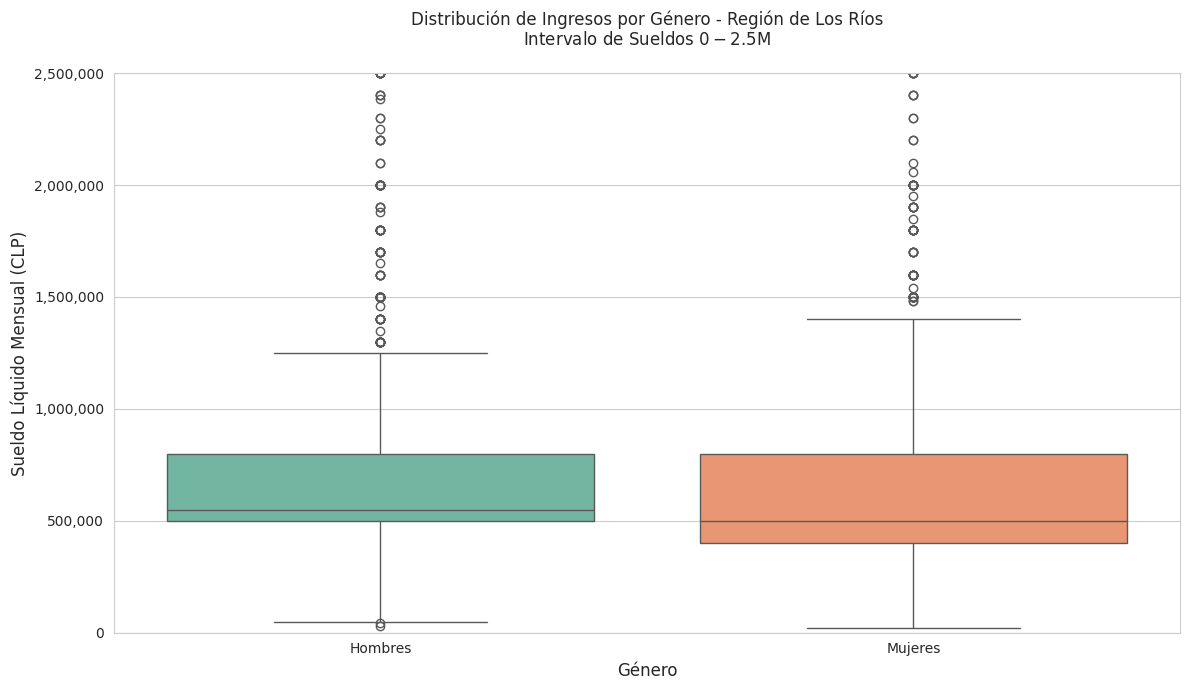

In [7]:
#Mismo Gráfico de brecha de género pero considerando un rango de sueldo entre 0 y $2.5M para poder observar de mejor manera el promedio.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Cargar datos
df = pd.read_csv('datos_pobreza_valdivia.csv')

# 2. Limpieza estricta: Solo sueldos reales y conocidos
df_clean = df[df['y1'] > 0].copy()
df_clean['sexo'] = df_clean['sexo'].map({1: 'Hombres', 2: 'Mujeres'})

# 3. Configuración del gráfico
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Boxplot corregido (sin warnings y con colores institucionales)
ax = sns.boxplot(
    x='sexo', 
    y='y1', 
    data=df_clean, 
    palette='Set2', 
    hue='sexo', 
    legend=False,
    showfliers=True # Muestra los puntos, pero los limitaremos con el eje
)

# 4. Ajustes estéticos fundamentales
plt.title('Distribución de Ingresos por Género - Región de Los Ríos\nIntervalo de Sueldos $0-$2.5M', fontsize=12, pad=20)
plt.ylabel('Sueldo Líquido Mensual (CLP)', fontsize=12)
plt.xlabel('Género', fontsize=12)

# ZOOM: Nos enfocamos en el grueso de la población (0 a 2.5 Millones)
plt.ylim(0, 2500000)

# Formatear el eje Y para que ponga puntos en los miles (ej: 1.000.000)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()


In [ ]:
##Analisis del grafico de Distribución de Ingresos por Género
#La distribución de los sueldos líquidos revela una clara asimetría en perjuicio de las mujeres, 
#lo cual es un factor clave de vulnerabilidad económica:
#    Desventaja desde la base: La mediana salarial de las mujeres ($500.000) coincide exactamente con el primer cuartil (Q1) de los hombres. 
#    Es decir, el 50% de las mujeres trabajadoras gana lo mismo o menos que el 25% de los hombres con menores ingresos.
#    Mayor precariedad en el bloque central: La caja que agrupa al 50% central de las mujeres es más alargada porque arranca desde mucho 
#    más abajo ($400.000, muy cerca del sueldo mínimo), mientras que los hombres tienen un piso más sólido ($500.000). Ambos grupos topan 
#    en los $800.000, pero a las mujeres les cuesta más salir de la base de precariedad.
#    Techo salarial: Aunque matemáticamente el rango normal de las mujeres se estira un poco más arriba (el "bigote" llega a ~$1.4M debido 
#    a la dispersión de su caja), los valores atípicos (puntos negros) sobre los 1.5 millones de pesos se concentran visiblemente en los 
#    hombres. Los sueldos más altos de la región están masculinizados.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

try:
    # 1. Se lee el csv que generamos en la primera celda del notebook
    df = pd.read_csv('datos_pobreza_valdivia.csv')
    
    # 2. Ahora sí filtramos seguros
    df_sueldos = df[df['y1'].notna() & (df['y1'] > 0)].copy()
    df_sueldos['sexo'] = df_sueldos['sexo'].map({1: 'Hombres', 2: 'Mujeres'})
    
    # 3. Dibujamos el gráfico
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    ax = sns.boxplot(x='sexo', y='y1', data=df_sueldos, palette='Set2', hue='sexo', legend=False)
    
    plt.title('Distribución de Ingresos por Género (Escala Completa) - Los Ríos', fontsize=14)
    plt.ylabel('Sueldo Líquido Mensual (CLP)')
    plt.xlabel('Género')
    
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Ocurrió un error: {e}")
#1. Análisis de los Datos (Eje de Ingresos)
#    Participación Laboral: De las ~9.000 personas en la muestra de la región, solo 2.681 (un 29%) declaran un sueldo líquido (y1). El resto son probablemente menores de edad, estudiantes, personas dedicadas al cuidado del hogar o desempleados.
#    La Brecha de Género: * Hombres: El sueldo promedio es de $752.298, pero la mediana (el sueldo más común, el "centro") es de $550.000.
#        Mujeres: El sueldo promedio baja a $673.186, y la mediana cae a $500.000.
#        Conclusión: Hay una brecha de $50.000 mensuales solo en la mediana. Esto es un indicador directo de desigualdad de género en la región.
#    Desigualdad Extrema (Outliers): Mientras que el 75% de la población de la región gana menos de $800.000, existen casos aislados que ganan hasta $7.500.000. Estos "puntos" son los que estiran el gráfico hacia arriba y hacen que las cajas se vean pequeñas.
#    Calidad del Dato: El porcentaje de "No sabe/No responde" (-88) es bajísimo (menos del 0.5%), lo que significa que tu muestra es muy confiable para el análisis.

In [ ]:
#Distribución de pensiones de vejez por género
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Leemos el archivo fresquito
df = pd.read_csv('datos_pobreza_valdivia.csv')

# 2. Tu variable de pensiones
var_pension = 'y29_2b'

# 3. Filtramos descartando los vacíos y los ceros (solo nos interesan los que sí reciben pensión)
df_pensiones = df[df[var_pension].notna() & (df[var_pension] > 0)].copy()

print(f"Total de personas con pensión de vejez válida: {len(df_pensiones)}")

# 4. Mapeamos géneros
df_pensiones['sexo'] = df_pensiones['sexo'].map({1: 'Hombres', 2: 'Mujeres'})

# 5. Graficamos
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.boxplot(x='sexo', y=var_pension, data=df_pensiones, palette='Set2', hue='sexo', legend=False)

plt.title('Distribución de Pensiones de Vejez por Género - Región de Los Ríos', fontsize=14, pad=15)
plt.ylabel('Monto de la Pensión (CLP)', fontsize=12)
plt.xlabel('Género', fontsize=12)

# Formato para que los millones se lean claro
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()